# Predicting Solubility

We will use the following two methods to predict the solubility of compounds:

1. Linear regression for learning continuous values.
2. Logistic regression for classification.

The package we will use is `scikit-learn`: https://scikit-learn.org/stable/index.html, imported as `sklearn`.

In the `sklearn.linear_model` module, we call the following functions:

1. `LinearRegression`: for learning a continuous value
2. `Ridge`: for Ridge Regression (linear regression + L2 regularization)
3. `Lasso`: for Lasso Regression (linear regression + L1 regularization)
4. `LogisticRegression`: for classification




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # used to split the dataset into training and testing subsets
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression # models
from sklearn.preprocessing import StandardScaler # rescale the feature values
from sklearn import metrics # metrics for performance

### Get the data used in this lab

In [2]:
!mkdir -p "lab5"
!wget -q -O "lab5/delaney_solubility.csv" "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab5/data/delaney_solubility.csv"

In [3]:
# Read the CSV file to a data frame and examine it
df = pd.read_csv("lab5/delaney_solubility.csv", index_col=False)
print(df.columns) # you can see what columns are there
df.head() #see the first 5 rows

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles'],
      dtype='object')


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## Predicting Solubility with Linear Regression
We will predict the column `measured log solubility in mols per litre` with other features:

`Minimum Degree`, `Molecular Weight`, `Number of H-Bond Donors`,
       `Number of Rings`, `Number of Rotatable Bonds`, `Polar Surface Area`,

The column 'ESOL predicted log solubility in mols per litre' is predicted value by Delaney in this paper: https://pubs.acs.org/doi/10.1021/ci034243x using a simple linear regression model based on 4 features (see the paper).

Here we have six slightly different features, and let's see how our regression model performs.



In [4]:
# target
y = df["measured log solubility in mols per litre"].values

# features
feature_cols = [
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area",
]
X = df[feature_cols].values # each column of X is one feature

### Let's first examine the data

1. Distribution of the $y$ values
2. Correlation of the $x$ values



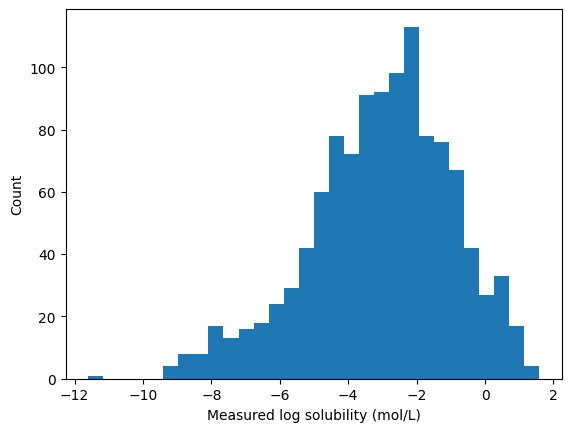

In [5]:
plt.hist(y, bins=30)
plt.xlabel("Measured log solubility (mol/L)")
plt.ylabel("Count")
plt.show()

### Correlation among features  
We can use the internal functions in Pandas to evaluate the correlation among different columns: `df.corr()`, where `df` is a Pandas DataFrame.

By default, Pandas uses Pearson correlation.

This gives us a matrix.


<Axes: >

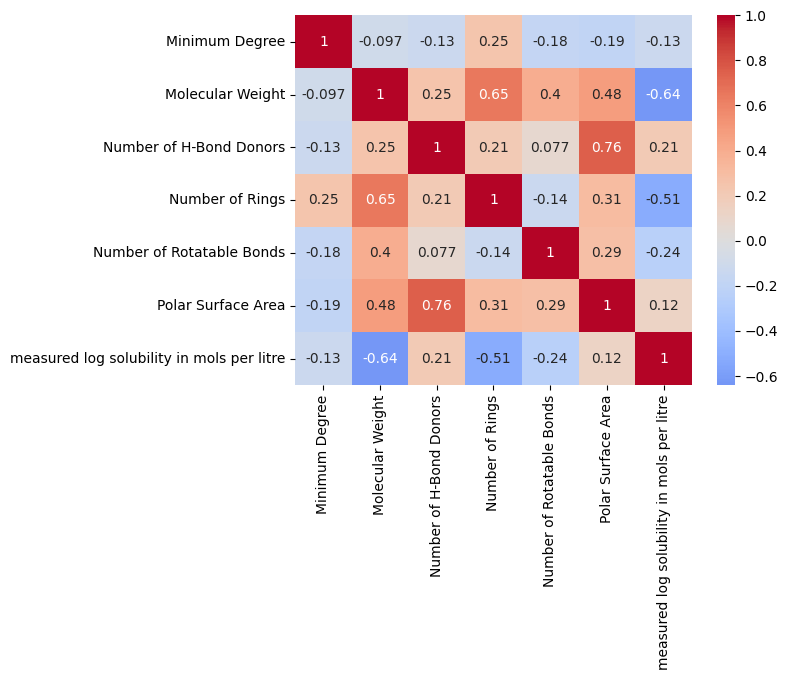

In [6]:
# evaluate correlation
corr = df[feature_cols + ["measured log solubility in mols per litre"]].corr()
import seaborn as sns # let's use seaborn to do the visualization
sns.heatmap(
    corr,
    xticklabels=corr.columns,
    yticklabels=corr.columns, # you should choose shorter column names for tight plotting...
    annot=True, # put numbers in each pixel
    cmap="coolwarm",
    center=0 # the value that shows neutral color
)

In [7]:
print(corr["measured log solubility in mols per litre"].sort_values()) # this tells us the correlation between y and different features
# print(corr["Molecular Weight"].sort_values())

Molecular Weight                            -0.640189
Number of Rings                             -0.512279
Number of Rotatable Bonds                   -0.244256
Minimum Degree                              -0.130445
Polar Surface Area                           0.123210
Number of H-Bond Donors                      0.209429
measured log solubility in mols per litre    1.000000
Name: measured log solubility in mols per litre, dtype: float64


## Let's start the training!

1. Split the dataset into the training and testing subsets
2. Perform linear regression

In [8]:
# split data into train and test sets
# almost all ML libraries have their own train-test split functions
# random_state is the seed for random number generator, if not specified, the split will be different each time
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=None
)

In [9]:
# linear regression
linreg = LinearRegression() # initiate the linear regression object
linreg.fit(X_train, y_train) # train the data

y_pred = linreg.predict(X_test) # get prediction

rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, y_pred)) # RMSE score
r2_lr = metrics.r2_score(y_test, y_pred) # R2 score

print(rmse_lr, r2_lr)


1.1553998021370422 0.6931172106761159


In [10]:
# Let's look at the coefficients
print(linreg.intercept_) # theta_0
print(linreg.coef_) # coefficients theta_1 to theta_n
print(feature_cols)

-0.040526197510689865
[-0.48254808 -0.0139215   0.0588089  -0.37135555 -0.14282386  0.03267652]
['Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area']


In [ ]:
# we could also use pandas to print the table of the above
print(pd.Series(linreg.coef_, index=feature_cols)) # Pandas Series creates a labeled 1D vector (array)

Minimum Degree              -0.664586
Molecular Weight            -0.013150
Number of H-Bond Donors      0.123428
Number of Rings             -0.396033
Number of Rotatable Bonds   -0.140794
Polar Surface Area           0.029794
dtype: float64


## Improve the model

### 1. Rescaling

In [11]:
# let's try to rescale the features
scaler = StandardScaler() # initiate the StandardScaler object
X_train_scaled = scaler.fit_transform(X_train) # fit_transform finds out the rescaling factors and store them
X_test_scaled = scaler.transform(X_test) # use transform! so you are using the same rescaling factors as the training data

In [12]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred = linreg.predict(X_test_scaled)

rmse_lr = np.sqrt(metrics.mean_squared_error(y_test, y_pred)) # lower mse is better
r2_lr = metrics.r2_score(y_test, y_pred) # large r2 score is better

print(rmse_lr, r2_lr)

# Rescaling didn't help here... our data is good enough

1.155399802137042 0.6931172106761161


### Add regularization

In [14]:
# L1 Regularization - Lasso
lasso = Lasso(alpha=0.1)  # alpha = regularization strength; play with the value!
lasso.fit(X_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso.predict(X_test_scaled)

# Metrics
rmse_lasso = np.sqrt(metrics.mean_squared_error(y_test, y_pred_lasso))
r2_lasso = metrics.r2_score(y_test, y_pred_lasso)
print("Lasso RMSE:", rmse_lasso, "R2:", r2_lasso)

# # Coefficients
# pd.Series(lasso.coef_, index=feature_cols)

Lasso RMSE: 1.1855677852293993 R2: 0.6768823101562645


In [15]:
# L2 regularization - Ridge
ridge = Ridge(alpha=0.01)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(metrics.mean_squared_error(y_test, y_pred_ridge))
r2_ridge = metrics.r2_score(y_test, y_pred_ridge)
print("Ridge RMSE:", rmse_lasso, "R2:", r2_lasso)


Ridge RMSE: 1.1855677852293993 R2: 0.6768823101562645


### Why is adding regularization worse?
The original problem is already low-dimensional, well-conditioned, and near-optimal with ordinary least squares.

Adding regularization introduces bias without meaningfully reducing variance.

In practice, you should be careful on choosing these hyperparameters.

# Logistic Regression for Classification

Now let's label the solubility and turn the problem into a classification problem.

We define the following classes:

1. High solubility (y=1): measured log solubility >= the average value.
2. Low solubility (y=0): measured log solubility < the average value.

We will add a new column to the DataFrame.

In [17]:
# create the labels
y_label = (df["measured log solubility in mols per litre"] >=
     df["measured log solubility in mols per litre"].median()).astype(int) # turn True or False into 1 or 0

In [18]:
print(y_label)

0       1
1       0
2       1
3       0
4       1
       ..
1123    1
1124    1
1125    0
1126    0
1127    0
Name: measured log solubility in mols per litre, Length: 1128, dtype: int64


In [19]:
# add y into the data frame we have
df["solubility_label"] = y_label
print(df.columns) # we have an extra column now!

Index(['Compound ID', 'ESOL predicted log solubility in mols per litre',
       'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors',
       'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area',
       'measured log solubility in mols per litre', 'smiles',
       'solubility_label'],
      dtype='object')


In [20]:
# we can save to a new file for future reference
# Note your saved file will disappear in Colab if you close the window.
df.to_csv("lab5/delaney_solubility_labeled.csv", index=False)

### Now let's start training


In [21]:
# split training and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_label, test_size=0.2, random_state=42, stratify=y_label
)
# adding stratify ensures that the train and test sets have the same class proportion as the original dataset.

In [22]:
# scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# initialize the logistic regression object
clf = LogisticRegression(
    penalty="l2", # L2 regularization
    C=0.5, # strength of regularization, play with these parameters!
    max_iter=1000,
    solver="lbfgs" # optimization method
)

In [29]:
# start training
clf.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, max_iter=1000)

In [30]:
# predictions
y_pred = clf.predict(X_test_scaled) # labels 0 and 1
y_prob = clf.predict_proba(X_test_scaled)[:, 1] # the sigmoid function value

In [31]:
# evaluation
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("ROC AUC:", metrics.roc_auc_score(y_test, y_prob))
print(metrics.classification_report(y_test, y_pred))

Accuracy: 0.8362831858407079
ROC AUC: 0.911895998120448
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       113
           1       0.82      0.86      0.84       113

    accuracy                           0.84       226
   macro avg       0.84      0.84      0.84       226
weighted avg       0.84      0.84      0.84       226



In [27]:
# coefficients and bias
coef = clf.coef_[0]
intercept = clf.intercept_[0]
for name, c in zip(feature_cols, coef):
    print(f"{name:30s}: {c:.4f}")
print("Intercept:", intercept)

Minimum Degree                : -0.0161
Molecular Weight              : -1.6320
Number of H-Bond Donors       : 0.4425
Number of Rings               : -1.0236
Number of Rotatable Bonds     : -0.6332
Polar Surface Area            : 0.9941
Intercept: -0.25023015211260996


## Play with the regularization for logistic regression
Logistic is more sensitive to regularization than linear regression due to the non-linear sigmoid function.